# Predictive Crop Recommendation Using Soil Nutrients)

Measuring essential soil metrics such as nitrogen, phosphorous, potassium levels, and pH value is an important aspect of assessing soil condition. However, it can be an expensive and time-consuming process, which can cause farmers to prioritize which metrics to measure based on their budget constraints.

Farmers have various options when it comes to deciding which crop to plant each season. Their primary objective is to maximize the yield of their crops, taking into account different factors. One crucial factor that affects crop growth is the condition of the soil in the field, which can be assessed by measuring basic elements such as nitrogen and potassium levels. Each crop has an ideal soil condition that ensures optimal growth and maximum yield.



In [1]:
# IMPORTS
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("soil_measures.csv")

In [3]:
df.head()

,N,P,K,ph,crop
0,90,42,43,6.502985,rice
1,85,58,41,7.038096,rice
2,60,55,44,7.840207,rice
3,74,35,40,6.980401,rice
4,78,42,42,7.628473,rice


In [4]:
df.shape

(2200, 5)

In [5]:
df.columns

Index(['N', 'P', 'K', 'ph', 'crop'], dtype='object')

In [6]:
df.describe()

,N,P,K,ph
count,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,6.469480
std,36.917334,32.985883,50.647931,0.773938
min,0.000000,5.000000,5.000000,3.504752
25%,21.000000,28.000000,20.000000,5.971693
50%,37.000000,51.000000,32.000000,6.425045
75%,84.250000,68.000000,49.000000,6.923643
max,140.000000,145.000000,205.000000,9.935091


In [7]:
# Check for missing values

df.isna().sum() 

N       0
P       0
K       0
ph      0
crop    0
dtype: int64

In [8]:
# Check for crop types

df["crop"].unique()

array(['rice', 'maize', 'chickpea', 'kidneybeans', 'pigeonpeas',
       'mothbeans', 'mungbean', 'blackgram', 'lentil', 'pomegranate',
       'banana', 'mango', 'grapes', 'watermelon', 'muskmelon', 'apple',
       'orange', 'papaya', 'coconut', 'cotton', 'jute', 'coffee'],
      dtype=object)

<Axes: xlabel='crop'>

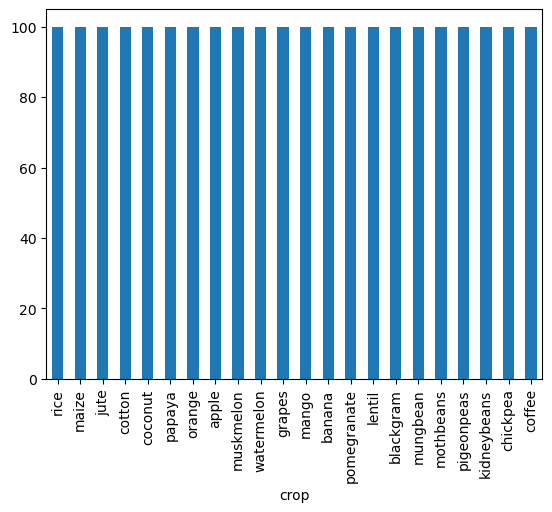

In [9]:
# Crop Distribution

df["crop"].value_counts().plot(kind="bar")

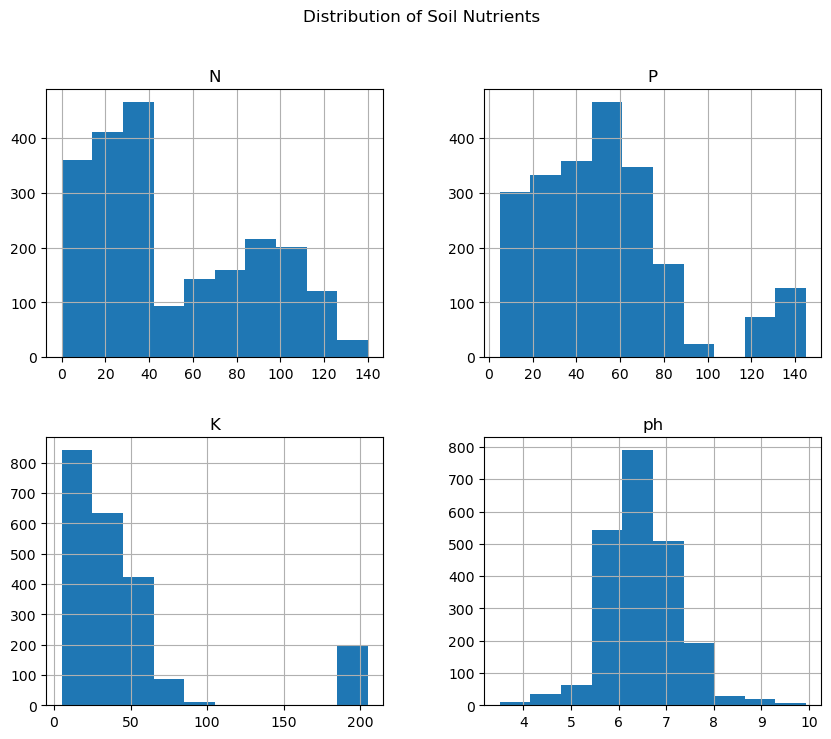

In [10]:
# Nutrient Distribution

df[["N", "P", "K", "ph"]].hist(figsize=(10,8))
plt.suptitle("Distribution of Soil Nutrients")
plt.show()

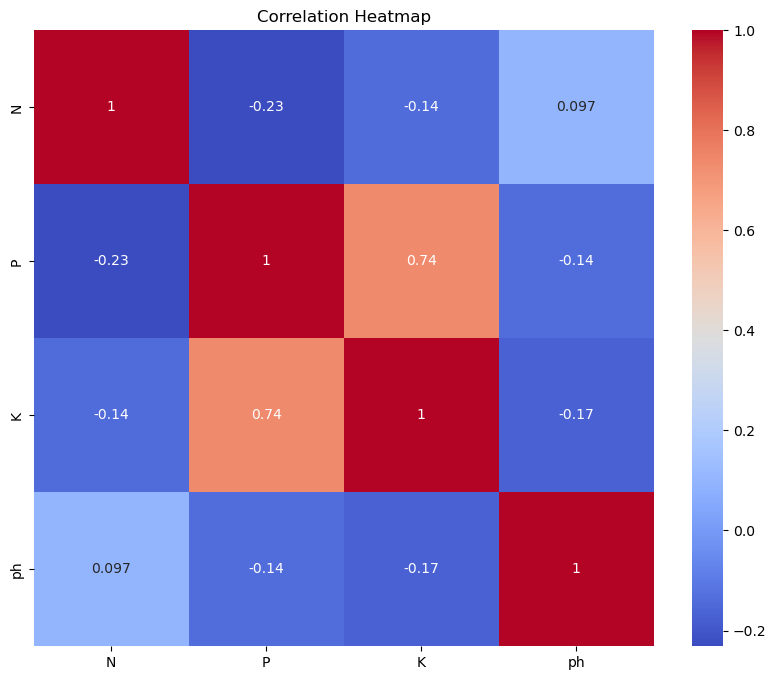

In [11]:
# Correlation Heatmap

# +1 → Perfect positive relationship: as one variable increases, the other increases.
# 0 → No linear relationship.
# -1 → Perfect negative relationship: as one variable increases, the other decreases.

plt.figure(figsize=(10,8))

sns.heatmap(
    df.drop("crop", axis=1).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

In [12]:
# Features and target variables
X = df.drop("crop", axis=1)
y = df["crop"]

In [13]:
# check for class imbalance
y.value_counts()

crop
rice           100
maize          100
jute           100
cotton         100
coconut        100
papaya         100
orange         100
apple          100
muskmelon      100
watermelon     100
grapes         100
mango          100
banana         100
pomegranate    100
lentil         100
blackgram      100
mungbean       100
mothbeans      100
pigeonpeas     100
kidneybeans    100
chickpea       100
coffee         100
Name: count, dtype: int64

In [14]:
# Evaluate feature performance
# Find which individual feature is most useful for predicting the crop. 
# **Logistic Regression converges much faster when features are standardized.

features = ["N", "P", "K", "ph"]

features_dict = {}

for feature in features:
    X = df[[feature]]
    y = df["crop"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42
    )

    # Scale the feature
    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Train model
    model = LogisticRegression(max_iter=1000)

    model.fit(X_train, y_train)

    # Evaluate
    accuracy = model.score(X_test, y_test)

    features_dict[feature] = accuracy
    sorted_results = dict(sorted(features_dict.items(), key=lambda x: x[1]))
print(sorted_results)

{'ph': 0.09772727272727273, 'N': 0.15227272727272728, 'P': 0.16590909090909092, 'K': 0.24545454545454545}


In [15]:
# Each loop does this: Pick one feature, Train model on it, Predict using it, Score it, Save result

features = ["N", "P", "K", "ph"]

X = df[features]
y = df["crop"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the feature
scaler = StandardScaler()

# this creates a numpy array
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# convert back to DataFrame after scaling
X_train = pd.DataFrame(X_train, columns=features)
X_test = pd.DataFrame(X_test, columns=features)

features_dict = {}

for feature in features:

    # create model
    log_reg = LogisticRegression()

    # train model
    log_reg.fit(X_train[[feature]], y_train)

    # predict on test set
    y_pred = log_reg.predict(X_test[[feature]])

    print(f"\nResults using {feature}:")
    print(pd.DataFrame({
    "Actual": y_test.values[:5], # compare predictions with the actual values:
    "Predicted": y_pred[:5]
    }))

    # evaluate accuracy
    accuracy = log_reg.score(X_test[[feature]], y_test)

    # store result
    features_dict[feature] = accuracy

# Find best feature
best_feature = max(features_dict, key=features_dict.get)
best_accuracy = features_dict[best_feature]

print(features_dict)
print(f"\nThe best predictor is '{best_feature}' with an accuracy of {best_accuracy:.2%}")


Results using N:
       Actual  Predicted
0   muskmelon     coffee
1  watermelon  muskmelon
2      papaya     papaya
3      papaya  blackgram
4       apple     grapes

Results using P:
       Actual Predicted
0   muskmelon    orange
1  watermelon    orange
2      papaya    lentil
3      papaya    papaya
4       apple    grapes

Results using K:
       Actual  Predicted
0   muskmelon  muskmelon
1  watermelon  muskmelon
2      papaya  muskmelon
3      papaya  muskmelon
4       apple     grapes

Results using ph:
       Actual  Predicted
0   muskmelon     grapes
1  watermelon  muskmelon
2      papaya     lentil
3      papaya     lentil
4       apple      mango
{'N': 0.15227272727272728, 'P': 0.16590909090909092, 'K': 0.24545454545454545, 'ph': 0.09772727272727273}

The best predictor is 'K' with an accuracy of 24.55%


# Feature	Question

N	“How well does nitrogen alone predict crop?”

P	“How well does phosphorus alone predict crop?”

K	“How well does potassium alone predict crop?”

ph	“How well does pH alone predict crop?”

In [16]:
from sklearn.metrics import f1_score

feature_performance_dict = {}

for feature in features:

    log_reg = LogisticRegression()

    log_reg.fit(X_train[[feature]], y_train)

    y_pred = log_reg.predict(X_test[[feature]])

    feature_performance = f1_score(
        y_test,
        y_pred,
        average="weighted"
    )

    feature_performance_dict[feature] = feature_performance

    print(f"F1-score for {feature}: {feature_performance}")

best_feature = max(feature_performance_dict, key=feature_performance_dict.get)

best_predictive_feature = {
    best_feature: feature_performance_dict[best_feature]
}

print(feature_performance_dict)
print(best_predictive_feature)

F1-score for N: 0.11009290679319904
F1-score for P: 0.08426955444720075
F1-score for K: 0.13831456375684123
F1-score for ph: 0.045464856528065166
{'N': 0.11009290679319904, 'P': 0.08426955444720075, 'K': 0.13831456375684123, 'ph': 0.045464856528065166}
{'K': 0.13831456375684123}


### Insight

Potassium achieved the highest predictive performance among the individual soil metrics, suggesting that crop selection is more sensitive to potassium variation than nitrogen, phosphorus, or pH when considered independently.

# Training one model using all 4 features together (N, P, K, pH) instead of one at a time. (multi-class crop prediction without hyperparameter tuning)

In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Features and target
features = ["N", "P", "K", "ph"]
X = df[features]
y = df["crop"]

# Encode target (crop labels → numbers)
le = LabelEncoder()
y = le.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model (multiclass logistic regression)
model = LogisticRegression(
    max_iter=1000
)

# Train model
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.6590909090909091


In [18]:
# Optional (VERY useful): see real crop names again Right now predictions are numbers (0,1,2,...). To convert back:

y_pred_labels = le.inverse_transform(y_pred)

# And compare:

y_test_labels = le.inverse_transform(y_test)

results = pd.DataFrame({
    "Actual": y_test_labels,
    "Predicted": y_pred_labels
})

print(results)

         Actual   Predicted
0     muskmelon   muskmelon
1    watermelon   muskmelon
2        papaya      papaya
3        papaya      papaya
4         apple       apple
..          ...         ...
435        rice        rice
436        rice        jute
437      cotton      cotton
438      cotton      cotton
439  pigeonpeas  pigeonpeas

[440 rows x 2 columns]


# Training one model using all 4 features together (N, P, K, pH). After hyperparameter tuning ((multi-class crop prediction)

# BUILD A RANDOMIZED SEARCH CV

In [19]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression

# SETUP THE SAMPLE SPACE
C = [0.0001, 0.001, 0.01, 0.05, 0.1, 0.5, 1, 5, 10, 100]
penalty = ['l1', 'l2']
solver = ['liblinear', 'saga']
class_weight = [None, 'balanced']
max_iter = [100, 300, 500, 1000, 2000]


# create the grid
param_grid = {
    'C':C,
    'penalty': penalty,
    'solver': solver ,
    'class_weight': class_weight,
    'max_iter': max_iter
}

random_search = RandomizedSearchCV(
    estimator=LogisticRegression(),
    param_distributions=param_grid,
    n_iter=50,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    refit=True,
    return_train_score=True
)

random_search.fit(X_train, y_train)

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,estimator,LogisticRegression()
,param_distributions,"{'C': [0.0001, 0.001, ...], 'class_weight': [None, 'balanced'], 'max_iter': [100, 300, ...], 'penalty': ['l1', 'l2'], ...}"
,n_iter,50
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [20]:
# get the best hyperparameters

random_search.best_params_

{'solver': 'saga',
 'penalty': 'l1',
 'max_iter': 500,
 'class_weight': None,
 'C': 10}

In [21]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Features and target
features = ["N", "P", "K", "ph"]
X = df[features]
y = df["crop"]

# Encode target (crop labels → numbers)
le = LabelEncoder()
y = le.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model (multiclass logistic regression)
model = LogisticRegression(
    solver="saga",
    penalty="l1",
    max_iter=500,
    class_weight=None,
    C=10
)

# Train model
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.6931818181818182


C:\Users\USER\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [22]:
y_pred_labels = le.inverse_transform(y_pred)

# And compare:

y_test_labels = le.inverse_transform(y_test)

results = pd.DataFrame({
    "Actual": y_test_labels,
    "Predicted": y_pred_labels
})

print(results)

         Actual   Predicted
0     muskmelon   muskmelon
1    watermelon   muskmelon
2        papaya      papaya
3        papaya      papaya
4         apple       apple
..          ...         ...
435        rice        rice
436        rice        jute
437      cotton      cotton
438      cotton      cotton
439  pigeonpeas  pigeonpeas

[440 rows x 2 columns]


In [23]:
# increase max_iter and do cross validation

from sklearn.model_selection import cross_val_score

# 1. Prepare data
features = ["N", "P", "K", "ph"]
X = df[features]
y = df["crop"]

# 2. Encode target
le = LabelEncoder()
y = le.fit_transform(y)

# 3. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. Scale
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# 5. Create your tuned model
model = LogisticRegression(
    solver="saga",
    penalty="l1",
    max_iter=2000,
    C=10
)


# 6. Cross validation goes HERE
scores = cross_val_score(model, X_train, y_train, cv=5)

print("CV scores:", scores)
print("Average CV accuracy:", scores.mean())


# 7. Train final model
model.fit(X_train, y_train)


# 8. Test prediction
y_pred = model.predict(X_test)


# 9. Test accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Test accuracy:", accuracy)

CV scores: [0.71022727 0.74147727 0.67897727 0.71306818 0.68465909]
Average CV accuracy: 0.7056818181818182
Test accuracy: 0.6977272727272728


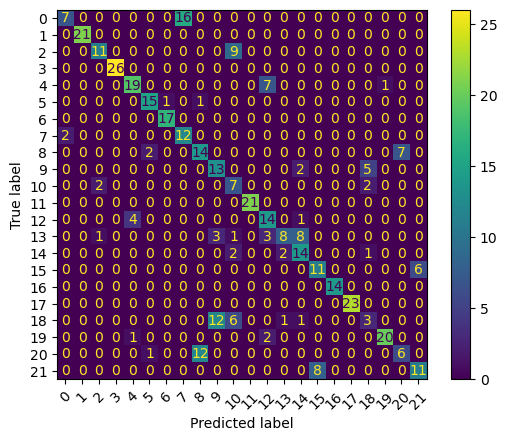

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    xticks_rotation=45
)

plt.show()

In [25]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.30      0.44        23
           1       1.00      1.00      1.00        21
           2       0.79      0.55      0.65        20
           3       1.00      1.00      1.00        26
           4       0.79      0.70      0.75        27
           5       0.83      0.88      0.86        17
           6       0.94      1.00      0.97        17
           7       0.43      0.86      0.57        14
           8       0.52      0.61      0.56        23
           9       0.46      0.65      0.54        20
          10       0.28      0.64      0.39        11
          11       1.00      1.00      1.00        21
          12       0.54      0.74      0.62        19
          13       0.73      0.33      0.46        24
          14       0.54      0.74      0.62        19
          15       0.58      0.65      0.61        17
          16       1.00      1.00      1.00        14
          17       1.00    

## the warning above is saying that the model never predicted some classes (crops).

So when sklearn tries to calculate precision for Wheat/Cotton:

Precision = Correct predictions / All predictions of that class

the denominator becomes zero because the model never predicted that class.

In [26]:
# check which crops the model is predicting:

import numpy as np

print(np.unique(y_test))
print(np.unique(y_pred))

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21]


# Conclusion

A baseline Logistic Regression model achieved an accuracy of 65%. Hyperparameter tuning was performed using RandomizedSearchCV, exploring different values for regularization strength (C), penalty type, solver, class weighting, and maximum iterations. The best-performing model used solver='saga', penalty='l1', C=10, and max_iter=500, improving test accuracy to 69%.

### Model Improvement: Increasing max_iter and Applying Cross-Validation

The initial Logistic Regression model achieved an accuracy of **65%** on the test set. After performing hyperparameter tuning using RandomizedSearchCV, the model improved to **69% accuracy** with the following parameters:

- Solver: `saga`
- Penalty: `l1`
- C: `10`
- max_iter: `500`

During evaluation, a `ConvergenceWarning` was observed, indicating that the model had not fully converged within the specified number of iterations. To address this, the `max_iter` parameter was increased from **500 to 2000**, allowing the optimization algorithm more time to find the best model coefficients.

Additionally, **5-fold cross-validation** was applied using `cross_val_score()` to evaluate the model's consistency across multiple training and validation splits instead of relying on a single train-test split.

The cross-validation results provided a more reliable estimate of model performance and showed that the model maintained a similar accuracy level across different folds.

After increasing `max_iter` and applying cross-validation:

- Test Accuracy remained approximately **69%**
- Model convergence improved
- Performance evaluation became more reliable

Although increasing `max_iter` improved the training process by allowing the model to converge, it did not significantly increase predictive accuracy. This suggests that further improvements may require feature engineering, adding more relevant features, or testing more complex machine learning models.

## Recommendations

1. Use More Features (Highest Impact)

If you're currently using only:

features = ["N", "P", "K", "ph"]

try including all relevant features:

features = ["N", "P", "K","temperature", "humidity", "ph", "rainfall"]

For crop recommendation datasets, environmental factors like temperature, humidity, and rainfall are often very predictive.

2. Expand the Hyperparameter Search. Try a wider range

3. Examine Feature Importance

With logistic regression, you can inspect coefficients:

coef_df = pd.DataFrame(
    model.coef_,
    columns=features
)

4. Try Different Models

Logistic Regression is a linear model. Crop prediction often benefits from models that capture nonlinear relationships.

Consider:

Random Forest, XGBoost, Decision Tree, K-Nearest Neighbors. For many crop recommendation datasets, Random Forest or XGBoost can outperform Logistic Regression.

5. feature Engineering